In [1]:
%%writefile .env
# сервак
SSH_HOST=213.176.113.161
SSH_USER=shad
SSH_PASSWORD=shad

# сама бдшка
DB_HOST=5432
DB_NAME=osv_database
DB_USER=shad_user
DB_PASS=shadbd

Overwriting .env


In [2]:
# !pip install sshtunnel psycopg2-binary python-dotenv "paramiko<4.0.0"
# !pip install asyncpg

In [3]:
import plotly.graph_objects as go
import pandas as pd
from OSVDataClient import OSVDataClient
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [4]:
db = OSVDataClient()

In [5]:
df = db.get_detailed_report()

In [6]:
df.columns

Index(['vulnerability_id', 'vulnerability_summary', 'vulnerability_published',
       'vulnerability_withdrawn', 'vulnerability_aliases',
       'vulnerability_upstream', 'vulnerability_related',
       'vulnerability_severity_score', 'vulnerability_cwe_id',
       'vulnerability_severity_text', 'package_ecosystem', 'package_name',
       'affected_severity', 'affected_ranges', 'introduced_version',
       'fixed_version', 'intro_date', 'commit_date', 'fixed_date',
       'days_vulnerable', 'range_processing_status'],
      dtype='object')

## Общий score для каждой экосистемы

Формула для расчета: F(db) = **(Weighted_Severety_Category) * 0.4 + (Weighted_Fix_Rate) * 0.6** 

**Weighted_Severety_Category** => \
    'CRITICAL' = 100, \
    'HIGH'     =  70, \
    'MEDIUM'   =  40, \
    'LOW'      =  20;

**Weighted_Fix_Rate** =>  \
    'CRITICAL' =   1, \
    'HIGH'     = 0.7, \
    'MEDIUM'   = 0.5, \
    'LOW'      = 0.2; 

In [13]:
# has_fix — проверяем список словарей, а не строку
data['has_fix'] = data['affected_ranges'].apply(
    lambda ranges: any(
        'fixed' in evt
        for rng in (ranges if isinstance(ranges, list) else [])
        for evt in (rng.get('events', []) if isinstance(rng, dict) else [])
    )
)

print(f"has_fix True: {data['has_fix'].sum():,}")
print(f"has_fix False: {(~data['has_fix']).sum():,}")

# Пересчитываем unfix
data['is_unfixed'] = (1 - data['has_fix'].astype(int)) * data['unfix_w']

eco_stats = data.groupby('package_ecosystem').agg(
    sev_sum=('sev_points', 'sum'),
    sev_count=('sev_points', 'count'),
    unfix_sum=('is_unfixed', 'sum'),
    unfix_w_sum=('unfix_w', 'sum'),
    total_vulns=('vulnerability_id', 'nunique')
)

eco_stats['severity_score'] = eco_stats['sev_sum'] / eco_stats['sev_count']
eco_stats['unfix_score'] = eco_stats['unfix_sum'] / eco_stats['unfix_w_sum'] * 100
eco_stats['final_score'] = eco_stats['severity_score'] * SEVERITY_MULTIPLIER + eco_stats['unfix_score'] * UNFIX_MULTIPLIER
eco_stats['health_score'] = 100 - eco_stats['final_score']
score_df = eco_stats.sort_values('health_score', ascending=False)[['total_vulns', 'severity_score', 'unfix_score', 'health_score']]

print(score_df)

has_fix True: 20,873
has_fix False: 4,392
                   total_vulns  severity_score  unfix_score  health_score
package_ecosystem                                                        
PyPI                      5088       55.546314    11.643349     70.795465
Go                        3816       56.132427    14.311561     68.960092
Maven                     6573       57.103396    17.758522     66.503529
npm                       6200       62.465569    27.669617     58.412003


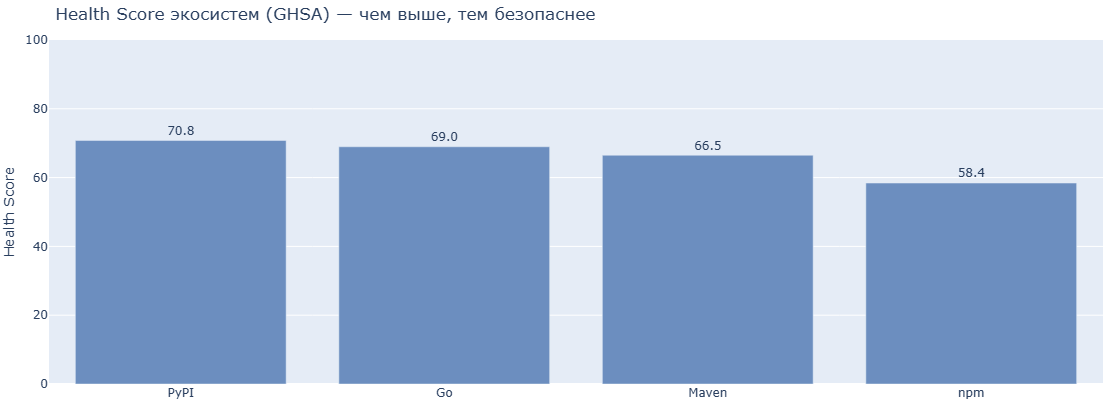

In [14]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Bar(
    x=score_df.index,
    y=score_df['health_score'],
    marker_color='#6C8EBF',
    text=[f'{s:.1f}' for s in score_df['health_score']],
    textposition='outside'
))
fig.update_layout(
    title="Health Score экосистем (GHSA) — чем выше, тем безопаснее",
    xaxis_title=None,
    yaxis_title="Health Score",
    yaxis=dict(range=[0, 100]),
    height=400,
    margin=dict(l=0, r=0, t=40, b=0)
)
fig.show()

## Grouped Bar Chart (по экосистемам и severety_category)

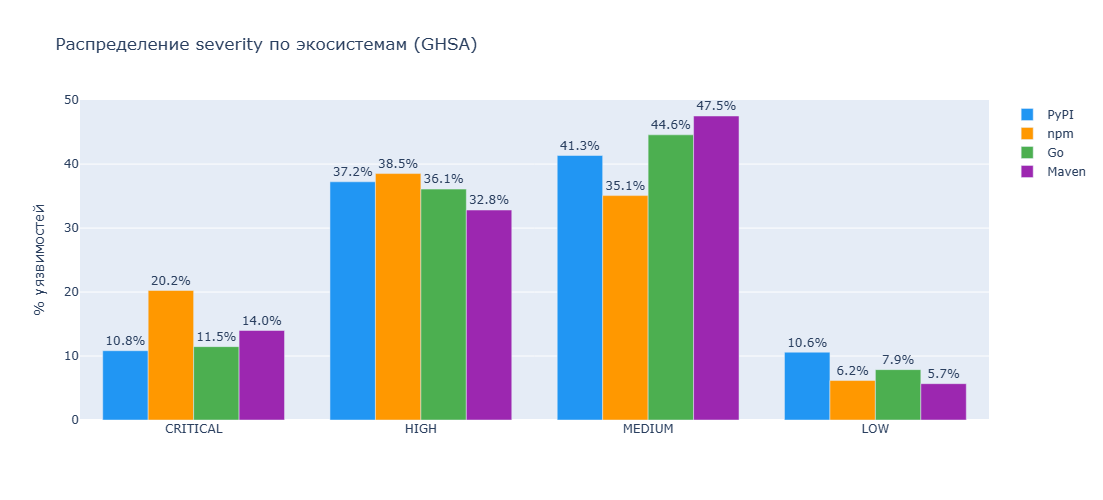

In [16]:
# Только GHSA + 4 экосистемы — с правильными колонками
ghsa = df[(df['vulnerability_id'].str.startswith('GHSA')) & (df['package_ecosystem'].isin(['PyPI', 'npm', 'Go', 'Maven']))]
ghsa['severity'] = ghsa['vulnerability_severity_text'].replace({'MODERATE': 'MEDIUM'})
ghsa = ghsa[ghsa['severity'].isin(['CRITICAL', 'HIGH', 'MEDIUM', 'LOW'])]

severity_order = ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']
colors = {'PyPI': '#2196F3', 'npm': '#FF9800', 'Go': '#4CAF50', 'Maven': '#9C27B0'}

fig = go.Figure()
for eco in ['PyPI', 'npm', 'Go', 'Maven']:
    subset = ghsa[ghsa['package_ecosystem'] == eco]
    total = len(subset)
    pcts = [(subset['severity'] == cat).sum() / total * 100 for cat in severity_order]
    fig.add_trace(go.Bar(
        x=severity_order, y=pcts, name=eco,
        marker_color=colors[eco],
        text=[f'{p:.1f}%' for p in pcts], textposition='outside'
    ))

fig.update_layout(
    title="Распределение severity по экосистемам (GHSA)",
    yaxis_title="% уязвимостей",
    height=500
)
fig.show()

## Детальный анализ для каждой экосистемы

In [21]:
from OSVDataClient import OSVDataClient
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

db = OSVDataClient()
# Один вызов — одна готовая таблица
df = db.get_detailed_report()

# Оставляем только GHSA и четыре экосистемы
df = df[
    (df['vulnerability_id'].str.startswith('GHSA')) &
    (df['package_ecosystem'].isin(['PyPI', 'npm', 'Go', 'Maven']))
].copy()

# Правильное определение has_fix (affected_ranges — список словарей)
def check_fix(ranges):
    if not isinstance(ranges, list):
        return False
    for rng in ranges:
        for evt in rng.get('events', []):
            if 'fixed' in evt:
                return True
    return False

df['has_fix'] = df['affected_ranges'].apply(check_fix)

# ФУНКЦИИ ДЛЯ ГРАФИКОВ 
def get_fix_rate(ecosystem):
    subset = df[df['package_ecosystem'] == ecosystem]
    return subset.groupby('package_name').agg(
        unique_vulns=('vulnerability_id', 'nunique'),
        fix_rate=('has_fix', 'mean')
    ).reset_index()

def get_cwe_data(ecosystem):
    subset = df[(df['package_ecosystem'] == ecosystem) &
                df['vulnerability_cwe_id'].notna() &
                (df['vulnerability_cwe_id'] != '')]
    all_cwe = []
    for cwe_str in subset['vulnerability_cwe_id']:
        for cwe in str(cwe_str).split('|'):
            cwe = cwe.strip()
            if cwe:
                all_cwe.append(cwe)
    return Counter(all_cwe).most_common(10), len(subset)

def plot_top_packages(ecosystem):
    pkg_stats = get_fix_rate(ecosystem)
    top = pkg_stats.nlargest(15, 'unique_vulns').sort_values('unique_vulns', ascending=True)
    
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.barh(top['package_name'], top['unique_vulns'], color='lightcoral', edgecolor='darkred', alpha=0.8, label='Всего')
    fixed = (top['unique_vulns'] * top['fix_rate']).astype(int)
    ax.barh(top['package_name'], fixed, color='mediumseagreen', edgecolor='darkgreen', alpha=0.9, label='Исправлено')
    for i, (val, rate) in enumerate(zip(top['unique_vulns'], top['fix_rate'])):
        ax.text(val + 0.5, i, f'{rate*100:.0f}%', va='center', fontsize=9)
    ax.set_title(f'Топ-15 пакетов {ecosystem}', fontsize=14)
    ax.legend(loc='lower right')
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

def plot_worst_packages(ecosystem, min_vulns=10):
    pkg_stats = get_fix_rate(ecosystem)
    worst = pkg_stats[pkg_stats['unique_vulns'] >= min_vulns].nsmallest(15, 'fix_rate').sort_values('fix_rate', ascending=True)
    
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.barh(worst['package_name'], worst['unique_vulns'], color='lightcoral', edgecolor='darkred', alpha=0.8, label='Всего')
    fixed = (worst['unique_vulns'] * worst['fix_rate']).astype(int)
    ax.barh(worst['package_name'], fixed, color='mediumseagreen', edgecolor='darkgreen', alpha=0.9, label='Исправлено')
    for i, (val, rate) in enumerate(zip(worst['unique_vulns'], worst['fix_rate'])):
        ax.text(val + 0.5, i, f'{rate*100:.0f}%', va='center', fontsize=9)
    ax.set_title(f'Худшие пакеты {ecosystem} (≥{min_vulns} уязв.)', fontsize=14)
    ax.legend(loc='lower right')
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

def plot_cwe(ecosystem):
    top10, total = get_cwe_data(ecosystem)
    cwes = [cwe for cwe, _ in top10][::-1]
    counts = [count for _, count in top10][::-1]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    colors = plt.cm.Blues(np.linspace(0.4, 0.9, 10))
    ax.barh(cwes, counts, color=colors, edgecolor='black', alpha=0.85)
    for bar, count in zip(ax.patches, counts):
        ax.text(bar.get_width() + max(counts)*0.01, bar.get_y() + bar.get_height()/2,
                f'{count} ({count/total*100:.1f}%)', va='center', fontsize=9)
    ax.set_title(f'Топ-10 CWE для {ecosystem} (всего: {total:,})', fontsize=14)
    ax.set_xlim(0, max(counts) * 1.25)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

def plot_all(ecosystem):
    print(f"АНАЛИЗ ЭКОСИСТЕМЫ: {ecosystem}")
    plot_top_packages(ecosystem)
    plot_worst_packages(ecosystem)
    plot_cwe(ecosystem)

АНАЛИЗ ЭКОСИСТЕМЫ: npm


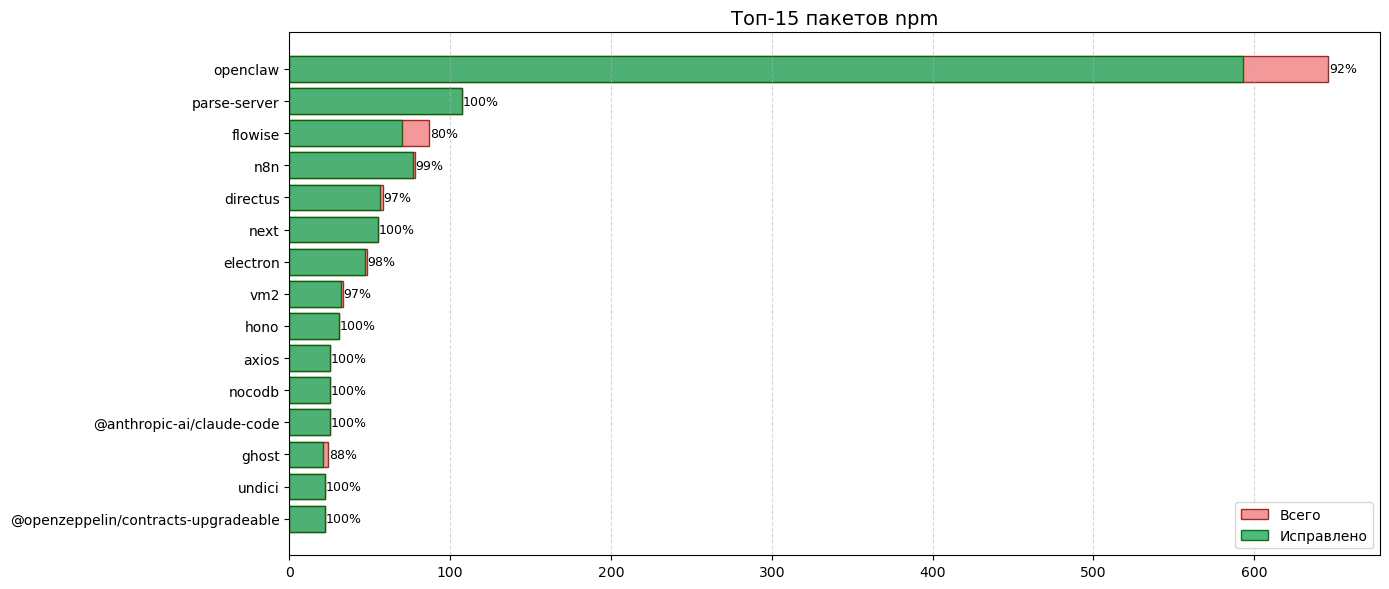

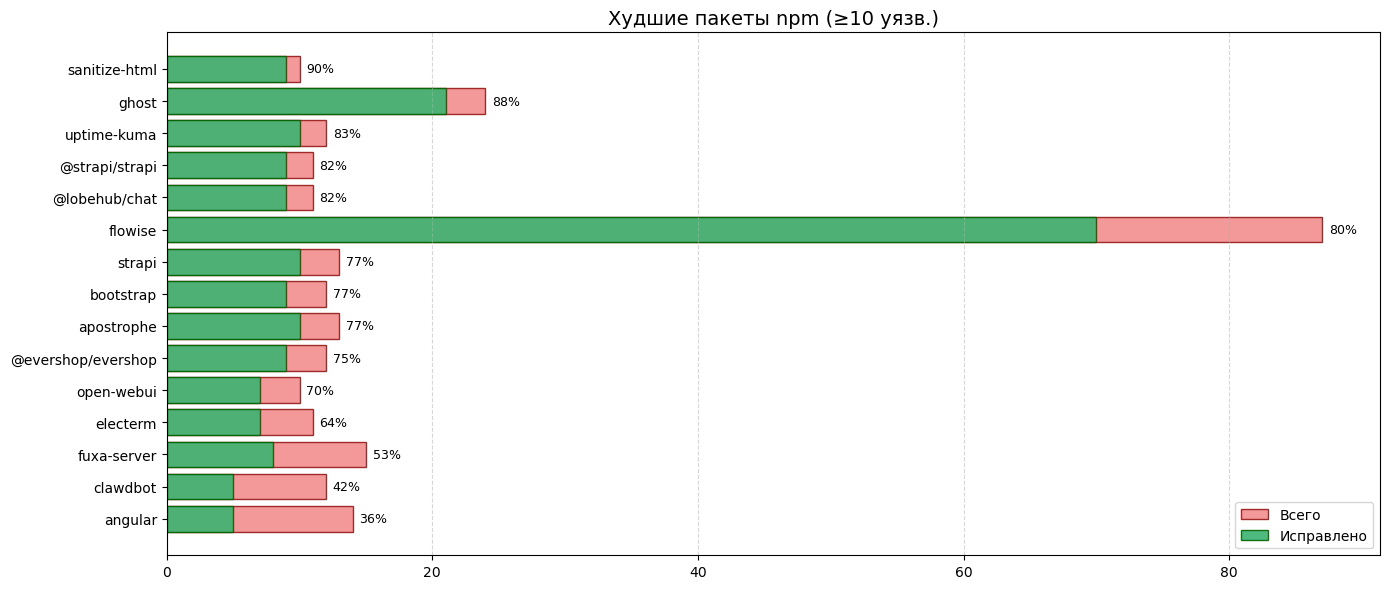

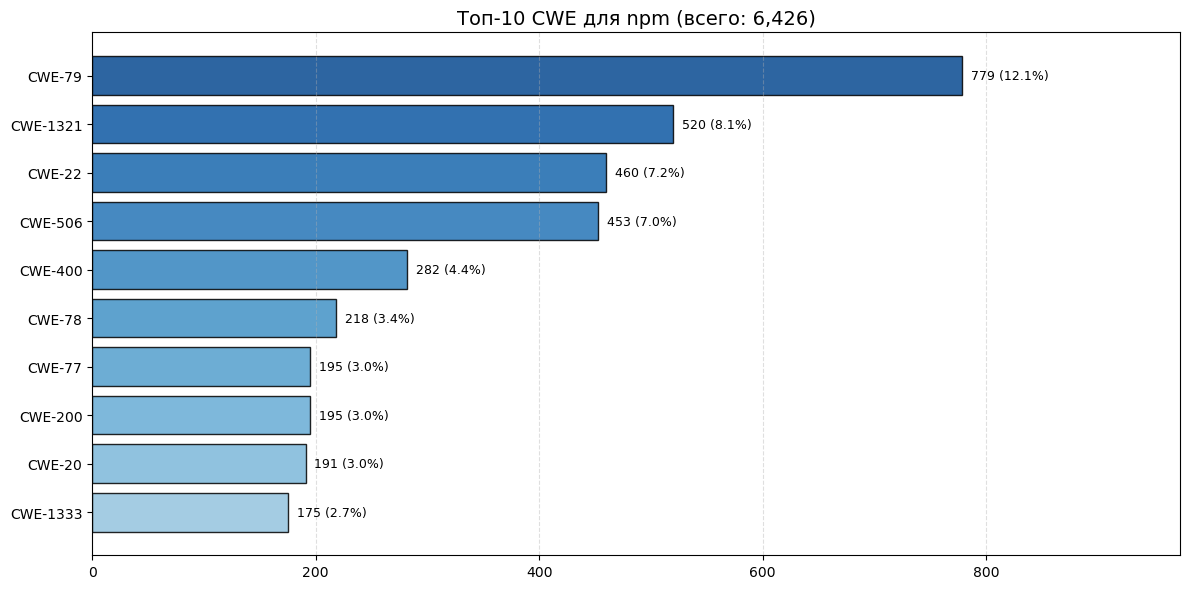

In [22]:
plot_all('npm')

## Multy-line Chart

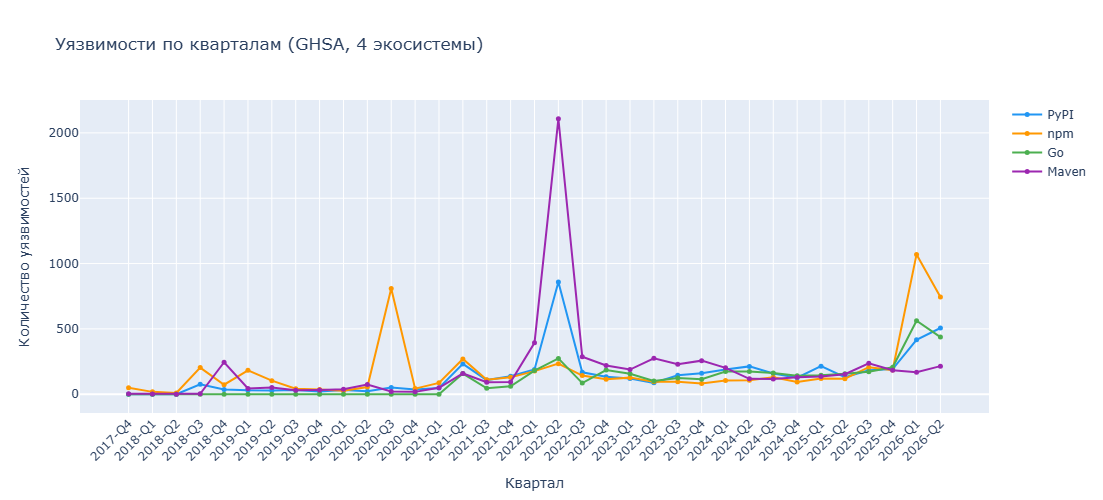

In [24]:
from OSVDataClient import OSVDataClient
import pandas as pd
import plotly.graph_objects as go

db = OSVDataClient()
# Один вызов — одна готовая таблица
df = db.get_detailed_report()

# Оставляем только GHSA и четыре экосистемы
df2 = df[
    (df['vulnerability_id'].str.startswith('GHSA')) &
    (df['package_ecosystem'].isin(['PyPI', 'npm', 'Go', 'Maven']))
].copy()

# Преобразуем дату публикации
df2['published_dt'] = pd.to_datetime(df2['vulnerability_published'])
df2['year'] = df2['published_dt'].dt.year
df2['quarter'] = df2['published_dt'].dt.quarter
df2['year_quarter'] = df2['year'].astype(str) + '-Q' + df2['quarter'].astype(str)

# Считаем уникальные уязвимости по кварталам и экосистемам
quarterly = df2.groupby(['year_quarter', 'package_ecosystem'])['vulnerability_id'].nunique().unstack(fill_value=0)
quarterly = quarterly[['PyPI', 'npm', 'Go', 'Maven']].sort_index()

colors = {'PyPI': '#2196F3', 'npm': '#FF9800', 'Go': '#4CAF50', 'Maven': '#9C27B0'}

fig = go.Figure()
for eco in ['PyPI', 'npm', 'Go', 'Maven']:
    fig.add_trace(go.Scatter(
        x=quarterly.index, y=quarterly[eco],
        mode='lines+markers', name=eco,
        line=dict(color=colors[eco], width=2),
        marker=dict(size=5)
    ))

fig.update_layout(
    title="Уязвимости по кварталам (GHSA, 4 экосистемы)",
    xaxis_title="Квартал",
    yaxis_title="Количество уязвимостей",
    height=500,
    width=1100,
    xaxis=dict(tickangle=-45)
)
fig.show()

## Топ инсайты

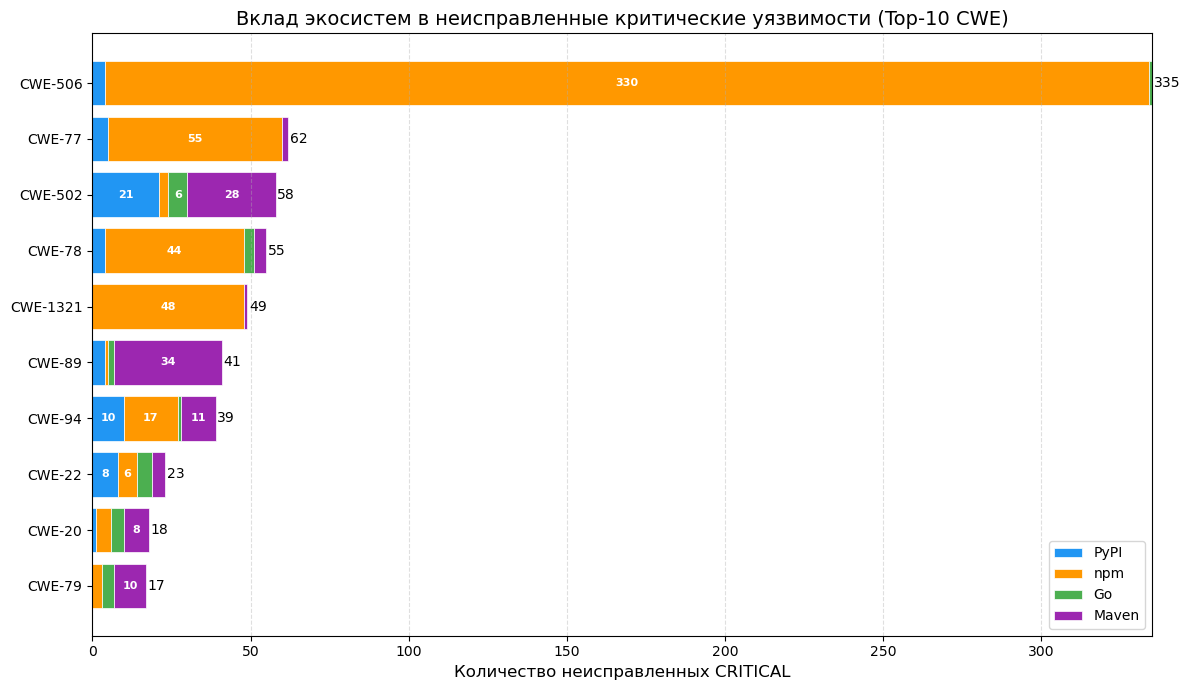

In [27]:
# Если cwe_df уже создан в предыдущей ячейке — используем его.
# Иначе пересоздадим (как в предыдущем ответе) через get_detailed_report
if 'cwe_df' not in dir():
    from OSVDataClient import OSVDataClient
    import pandas as pd
    db = OSVDataClient()
    df = await db.get_detailed_report()
    df = df[(df['vulnerability_id'].str.startswith('GHSA')) &
            (df['package_ecosystem'].isin(['PyPI', 'npm', 'Go', 'Maven']))].copy()
    df['severity'] = df['vulnerability_severity_text'].replace({'MODERATE': 'MEDIUM'})
    df = df[df['severity'].isin(['CRITICAL', 'HIGH', 'MEDIUM', 'LOW'])]
    def check_fix(ranges):
        if not isinstance(ranges, list): return False
        for rng in ranges:
            for evt in rng.get('events', []):
                if 'fixed' in evt: return True
        return False
    df['has_fix'] = df['affected_ranges'].apply(check_fix)
    df = df[df['vulnerability_cwe_id'].notna() & (df['vulnerability_cwe_id'] != '')]
    cwe_series = df['vulnerability_cwe_id'].str.split('|', expand=True).stack().str.strip()
    cwe_idx = cwe_series.index.get_level_values(0)
    cwe_df = df.loc[cwe_idx, ['severity', 'has_fix', 'package_ecosystem']].copy()
    cwe_df['cwe'] = cwe_series.values

# Только критические и неисправленные
crit_unfixed = cwe_df[(cwe_df['severity'] == 'CRITICAL') & (~cwe_df['has_fix'])]
# Топ-10 CWE по общему количеству неисправленных
top_cwe = crit_unfixed['cwe'].value_counts().head(10).index.tolist()
# Группировка по CWE и экосистеме
grouped = crit_unfixed[crit_unfixed['cwe'].isin(top_cwe)].groupby(['cwe', 'package_ecosystem']).size().unstack(fill_value=0)
# Порядок экосистем и цвета
ecosystems = ['PyPI', 'npm', 'Go', 'Maven']
colors = {'PyPI': '#2196F3', 'npm': '#FF9800', 'Go': '#4CAF50', 'Maven': '#9C27B0'}
# Сортируем по убыванию общей суммы
grouped['total'] = grouped.sum(axis=1)
grouped = grouped.sort_values('total', ascending=True)  # для горизонтального stacked bar снизу вверх

fig, ax = plt.subplots(figsize=(12, 7))
left = np.zeros(len(grouped))
for eco in ecosystems:
    if eco not in grouped.columns: continue
    values = grouped[eco].values
    bars = ax.barh(grouped.index, values, left=left, color=colors[eco], label=eco, edgecolor='white', linewidth=0.5)
    left += values
    # Подписи внутри сегментов, если достаточно места
    for bar, val in zip(bars, values):
        if val > 5:  # показываем количество в сегменте
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + bar.get_height()/2,
                    str(int(val)), ha='center', va='center', fontsize=8, color='white', fontweight='bold')

# Общие подписи справа
for i, (cwe, total) in enumerate(grouped['total'].items()):
    ax.text(total + 0.5, i, f'{int(total)}', va='center', fontsize=10)

ax.set_title('Вклад экосистем в неисправленные критические уязвимости (Top-10 CWE)', fontsize=14)
ax.set_xlabel('Количество неисправленных CRITICAL', fontsize=12)
ax.legend(loc='lower right')
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [28]:
from OSVDataClient import OSVDataClient
import pandas as pd

db = OSVDataClient()
df =  db.get_detailed_report()

# Фильтруем: GHSA + 4 экосистемы
df = df[(df['vulnerability_id'].str.startswith('GHSA')) & 
        (df['package_ecosystem'].isin(['PyPI', 'npm', 'Go', 'Maven']))].copy()

# Severity
df['severity'] = df['vulnerability_severity_text'].replace({'MODERATE': 'MEDIUM'})
df = df[df['severity'].isin(['CRITICAL', 'HIGH', 'MEDIUM', 'LOW'])]

# Длина summary по уникальным уязвимостям
vuln_summary = df.groupby('vulnerability_id').agg(
    severity=('severity', 'first'),
    summary_len=('vulnerability_summary', lambda x: len(str(x.iloc[0])) if pd.notna(x.iloc[0]) else 0)
).reset_index()

print("=" * 60)
print("ДЛИНА ОПИСАНИЯ (SUMMARY) vs SEVERITY")
print("=" * 60)
for sev in ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']:
    subset = vuln_summary[vuln_summary['severity'] == sev]
    empty = (subset['summary_len'] == 0).sum()
    print(f"\n{sev} (n={len(subset)}):")
    print(f"  Среднее: {subset['summary_len'].mean():.0f} симв.")
    print(f"  Медиана: {subset['summary_len'].median():.0f} симв.")
    print(f"  Пустых: {empty} ({empty/len(subset)*100:.0f}%)")

ДЛИНА ОПИСАНИЯ (SUMMARY) vs SEVERITY

CRITICAL (n=3170):
  Среднее: 57 симв.
  Медиана: 52 симв.
  Пустых: 0 (0%)

HIGH (n=7826):
  Среднее: 62 симв.
  Медиана: 59 симв.
  Пустых: 0 (0%)

MEDIUM (n=9017):
  Среднее: 64 симв.
  Медиана: 62 симв.
  Пустых: 0 (0%)

LOW (n=1496):
  Среднее: 66 симв.
  Медиана: 64 симв.
  Пустых: 0 (0%)


## Risk Matrix

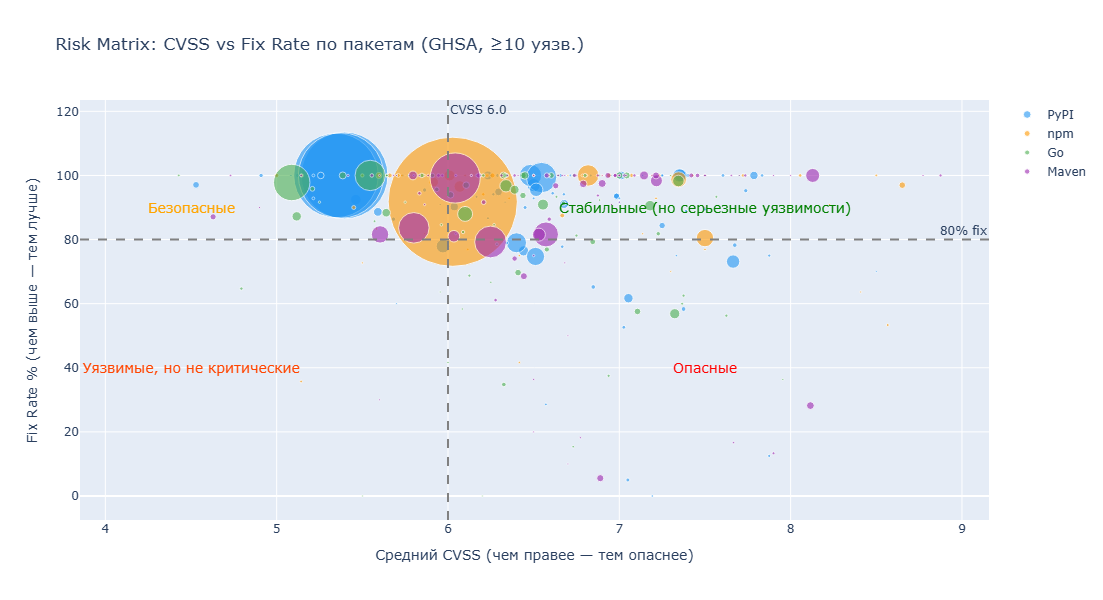

In [32]:
from OSVDataClient import OSVDataClient
import pandas as pd
import plotly.graph_objects as go

db = OSVDataClient()
df = db.get_detailed_report()

# Фильтруем: GHSA + 4 экосистемы
df = df[
    (df['vulnerability_id'].str.startswith('GHSA')) &
    (df['package_ecosystem'].isin(['PyPI', 'npm', 'Go', 'Maven']))
].copy()

# Severity
df['severity'] = df['vulnerability_severity_text'].replace({'MODERATE': 'MEDIUM'})
df = df[df['severity'].isin(['CRITICAL', 'HIGH', 'MEDIUM', 'LOW'])]

# Правильное определение has_fix
def check_fix(ranges):
    if not isinstance(ranges, list):
        return False
    for rng in ranges:
        for evt in rng.get('events', []):
            if 'fixed' in evt:
                return True
    return False

df['has_fix'] = df['affected_ranges'].apply(check_fix)

# Конвертируем severity в числа
severity_map = {'CRITICAL': 9.5, 'HIGH': 7.5, 'MEDIUM': 5.5, 'LOW': 2.5}
df['cvss_num'] = df['severity'].map(severity_map)

# По пакетам: средний CVSS и fix_rate (минимум 10 уязвимостей)
pkg_stats = df.groupby(['package_name', 'package_ecosystem']).agg(
    avg_cvss=('cvss_num', 'mean'),
    fix_rate=('has_fix', 'mean'),
    count=('vulnerability_id', 'nunique')
).reset_index()

pkg_stats = pkg_stats[pkg_stats['count'] >= 10]

# Risk matrix
colors_map = {'PyPI': '#2196F3', 'npm': '#FF9800', 'Go': '#4CAF50', 'Maven': '#9C27B0'}

fig = go.Figure()
for eco in ['PyPI', 'npm', 'Go', 'Maven']:
    subset = pkg_stats[pkg_stats['package_ecosystem'] == eco]
    fig.add_trace(go.Scatter(
        x=subset['avg_cvss'], y=subset['fix_rate'] * 100,
        mode='markers', name=eco,
        marker=dict(color=colors_map[eco], size=subset['count']/5, opacity=0.6),
        text=[f"{n}<br>CVSS: {c:.1f}<br>Fix: {f*100:.0f}%<br>Уязв: {cnt}" 
              for n, c, f, cnt in zip(subset['package_name'], subset['avg_cvss'], subset['fix_rate'], subset['count'])],
        hoverinfo='text'
    ))

# Квадранты — fix_rate=80%, CVSS=6.0
fig.add_hline(y=80, line_dash="dash", line_color="gray", annotation_text="80% fix")
fig.add_vline(x=6.0, line_dash="dash", line_color="gray", annotation_text="CVSS 6.0")

# Зоны
fig.add_annotation(x=7.5, y=90, text="Стабильные (но серьезные уязвимости)", showarrow=False, font=dict(color="green", size=14))
fig.add_annotation(x=7.5, y=40, text="Опасные", showarrow=False, font=dict(color="red", size=14))
fig.add_annotation(x=4.5, y=90, text="Безопасные", showarrow=False, font=dict(color="orange", size=14))
fig.add_annotation(x=4.5, y=40, text="Уязвимые, но не критические", showarrow=False, font=dict(color="orangered", size=14))

fig.update_layout(
    title="Risk Matrix: CVSS vs Fix Rate по пакетам (GHSA, ≥10 уязв.)",
    xaxis_title="Средний CVSS (чем правее — тем опаснее)",
    yaxis_title="Fix Rate % (чем выше — тем лучше)",
    height=600,
    hovermode='closest'
)
fig.show()